# Predicting Residential EV Charging Loads using Neural Networks

- [View Solution Notebook](./solutions.html)
- [View Project Page](https://www.codecademy.com/)

In [90]:
# Setup - import basic data libraries
import numpy as np
import os
import pandas as pd
import sys

## Task Group 1 - Load, Inspect, and Merge Datasets

### Task 1

The file `'datasets/EV charging reports.csv'` contains electric vehicle (EV) charging data. These come from various residential apartment buildings in Norway. The data includes specific user and garage information, plug-in and plug-out times, charging loads, and the dates of the charging sessions.

Import this CSV file to a pandas DataFrame named `ev_charging_reports`.

Use the `.head()` method to preview the first five rows.

In [91]:
os.getcwd()
os.listdir()

['Predicting Electric Vehicle Charging Loads.ipynb',
 'Dataset 1_EV charging reports.csv',
 'jbks2rcwyj-1.zip',
 'Dataset 3b_Hourly EV loads - Aggregated shared.csv',
 'Dataset 5_AMS data from garage Bl2.csv',
 'Dataset 2_Hourly EV loads - Per user.csv',
 'Dataset 3a_Hourly EV loads - Aggregated private.csv',
 'Dataset 6_Local traffic distribution.csv',
 '.gitignore',
 '.git',
 'README.md',
 '.ipynb_checkpoints',
 'models',
 'solutions.html',
 'Predicting Electric Vehicle Charging Loads.html']

In [92]:
print(sys.executable)

/home/anchang/miniforge3/envs/ev-pytorch/bin/python


In [104]:
ev_charging_reports = pd.read_csv("Dataset 1_EV charging reports.csv", sep=";")
ev_charging_reports.head()

,session_ID,Garage_ID,User_ID,User_type,Shared_ID,Start_plugin,Start_plugin_hour,End_plugout,End_plugout_hour,El_kWh,Duration_hours,month_plugin,weekdays_plugin,Plugin_category,Duration_category
0,1,AdO3,AdO3-4,Private,NaN,21.12.2018 10:20,10,21.12.2018 10:23,10.0,"0,3","0,05",Dec,Friday,late morning (9-12),Less than 3 hours
1,2,AdO3,AdO3-4,Private,NaN,21.12.2018 10:24,10,21.12.2018 10:32,10.0,"0,87","0,136666667",Dec,Friday,late morning (9-12),Less than 3 hours
2,3,AdO3,AdO3-4,Private,NaN,21.12.2018 11:33,11,21.12.2018 19:46,19.0,"29,87","8,216388889",Dec,Friday,late morning (9-12),Between 6 and 9 hours
3,4,AdO3,AdO3-2,Private,NaN,22.12.2018 16:15,16,23.12.2018 16:40,16.0,"15,56","24,41972222",Dec,Saturday,late afternoon (15-18),More than 18 hours
4,5,AdO3,AdO3-2,Private,NaN,24.12.2018 22:03,22,24.12.2018 23:02,23.0,"3,62","0,970555556",Dec,Monday,late evening (21-midnight),Less than 3 hours


In [113]:
ev_charging_reports["Start_plugin_hour"] = (
    pd.to_datetime(
        ev_charging_reports["Start_plugin"],
        format="%d.%m.%Y %H:%M"
    )
    .dt.floor("h")
    .dt.strftime("%d.%m.%Y %H:%M")
)

In [114]:
ev_charging_reports.columns

Index(['session_ID', 'Garage_ID', 'User_ID', 'User_type', 'Shared_ID',
       'Start_plugin', 'Start_plugin_hour', 'End_plugout', 'End_plugout_hour',
       'El_kWh', 'Duration_hours', 'month_plugin', 'weekdays_plugin',
       'Plugin_category', 'Duration_category'],
      dtype='object')

In [115]:
ev_charging_reports.shape

(6878, 15)

<details><summary style="display:list-item; font-size:16px; color:blue;">What is the structure of the dataset?</summary>

- **session_ID** - the unique id for each EV charging session
- **Garage_ID** - the unique id for the garage of the apartment
- **User_ID** - the unique id for each user
- **User_private** - 1.0 indicates private charge point spaces and 0.0 indicates shared charge point spaces
- **Shared_ID** - the unique id if shared charge point spaces are used
- **Start_plugin** - the plug-in date and time in the format (day.month.year hour:minute)
- **Start_plugin_hour** - the plug-in date and time rounded to the start of the hour
- **End_plugout** - the plug-out date and time in the format (day.month.year hour:minute)
- **End_plugout_hour** - the start of the hour of the `End_plugout` hour
- **El_kWh** - the charged energy in kWh (charging loads)
- **Duration_hours** - the duration of the EV connection time per session
- **Plugin_category** - the plug-in time categorized by early/late night, morning, afternoon, and evening
- **Duration_category** - the plug-in duration categorized by 3 hour groups
- **month_plugin_{month}** - the month of the plug-in session
- **weekdays_plugin_{day}** - the day of the week of the plug-in session

### Task 2

Import the file `'datasets/Local traffic distribution.csv'` to a pandas DataFrame named `traffic_reports`. This dataset contains the hourly local traffic density counts at 5 nearby traffic locations. 

Preview the first five rows.

In [116]:
traffic_reports = pd.read_csv("Dataset 6_Local traffic distribution.csv", sep=";")
traffic_reports.head()

,Date_from,Date_to,KROPPAN BRU,MOHOLTLIA,SELSBAKK,MOHOLT RAMPE 2,Jonsvannsveien vest for Steinanvegen
0,01.12.2018 00:00,01.12.2018 01:00,639,0,0,4,144
1,01.12.2018 01:00,01.12.2018 02:00,487,153,115,21,83
2,01.12.2018 02:00,01.12.2018 03:00,408,85,75,10,69
3,01.12.2018 03:00,01.12.2018 04:00,282,89,56,8,39
4,01.12.2018 04:00,01.12.2018 05:00,165,64,34,3,25


In [117]:
traffic_reports.columns

Index(['Date_from', 'Date_to', 'KROPPAN BRU', 'MOHOLTLIA', 'SELSBAKK',
       'MOHOLT RAMPE 2', 'Jonsvannsveien vest for Steinanvegen'],
      dtype='object')

In [118]:
traffic_reports.shape

(10248, 7)

<details><summary style="display:list-item; font-size:16px; color:blue;">What is the structure of the dataset?</summary>

- **Date_from** - the starting time in the format (day.month.year hour:minute)
- **Date_to** - the ending time in the format (day.month.year hour:minute)
- **Location 1 to 5** - contains the number of vehicles each hour at a specified traffic location.


### Task 3

We'd like to use the traffic data to help our model. The same charging location may charge at different rates depending on the number of cars being charged, so this traffic data might help the model out.

Merge the `ev_charging_reports` and `traffic_reports` datasets together into a Dataframe named `ev_charging_traffic` using the columns:

- `Start_plugin_hour` in `ev_charging_reports`
- `Date_from` in `traffic_reports`

In [119]:
print(ev_charging_reports["Start_plugin_hour"].dtype)
print(ev_charging_reports["Start_plugin"].dtype)
print(traffic_reports["Date_from"].dtype)
print(traffic_reports["Date_from"].head())

object
object
object
0    01.12.2018 00:00
1    01.12.2018 01:00
2    01.12.2018 02:00
3    01.12.2018 03:00
4    01.12.2018 04:00
Name: Date_from, dtype: object


In [150]:
ev_charging_traffic = ev_charging_reports.merge(traffic_reports, left_on="Start_plugin_hour", right_on="Date_from")
ev_charging_traffic.head()

,session_ID,Garage_ID,User_ID,User_type,Shared_ID,Start_plugin,Start_plugin_hour,End_plugout,End_plugout_hour,El_kWh,...,weekdays_plugin,Plugin_category,Duration_category,Date_from,Date_to,KROPPAN BRU,MOHOLTLIA,SELSBAKK,MOHOLT RAMPE 2,Jonsvannsveien vest for Steinanvegen
0,1,AdO3,AdO3-4,Private,NaN,21.12.2018 10:20,21.12.2018 10:00,21.12.2018 10:23,10.0,"0,3",...,Friday,late morning (9-12),Less than 3 hours,21.12.2018 10:00,21.12.2018 11:00,3244,1632,545,194,622
1,2,AdO3,AdO3-4,Private,NaN,21.12.2018 10:24,21.12.2018 10:00,21.12.2018 10:32,10.0,"0,87",...,Friday,late morning (9-12),Less than 3 hours,21.12.2018 10:00,21.12.2018 11:00,3244,1632,545,194,622
2,3,AdO3,AdO3-4,Private,NaN,21.12.2018 11:33,21.12.2018 11:00,21.12.2018 19:46,19.0,"29,87",...,Friday,late morning (9-12),Between 6 and 9 hours,21.12.2018 11:00,21.12.2018 12:00,3605,1691,605,230,771
3,4,AdO3,AdO3-2,Private,NaN,22.12.2018 16:15,22.12.2018 16:00,23.12.2018 16:40,16.0,"15,56",...,Saturday,late afternoon (15-18),More than 18 hours,22.12.2018 16:00,22.12.2018 17:00,3052,1484,453,224,694
4,5,AdO3,AdO3-2,Private,NaN,24.12.2018 22:03,24.12.2018 22:00,24.12.2018 23:02,23.0,"3,62",...,Monday,late evening (21-midnight),Less than 3 hours,24.12.2018 22:00,24.12.2018 23:00,1390,693,226,83,353


In [151]:
# Keep only rows where X and y have no NaNs
mask = ev_charging_traffic.notna().all(axis=1) 

ev_charging_traffic = ev_charging_traffic.loc[mask]

print(ev_charging_traffic.shape)

(1402, 22)


### Task 4

Use `.info()` to inspect the merged dataset. Specifically, pay attention to the data types and number of missing values in each column.

In [152]:
ev_charging_traffic.shape

(1402, 22)

In [153]:
ev_charging_traffic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1402 entries, 25 to 6877
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   session_ID                            1402 non-null   int64  
 1   Garage_ID                             1402 non-null   object 
 2   User_ID                               1402 non-null   object 
 3   User_type                             1402 non-null   object 
 4   Shared_ID                             1402 non-null   object 
 5   Start_plugin                          1402 non-null   object 
 6   Start_plugin_hour                     1402 non-null   object 
 7   End_plugout                           1402 non-null   object 
 8   End_plugout_hour                      1402 non-null   float64
 9   El_kWh                                1402 non-null   object 
 10  Duration_hours                        1402 non-null   object 
 11  month_plugin         

<details><summary style="display:list-item; font-size:16px; color:blue;">What do we notice about merged dataset under inspection?</summary>

We see that there are 39 columns and 6,833 rows in our merged dataset.

Some notable things we might have to address:

- We expected columns like `El_kWh` and `Duration_hours` to be floats but they are actually object data types.

- There are many identifying columns like `session_ID` and `User_ID` that might not be useful for training.

## Task Group 2 - Data Cleaning and Preparation

### Task 5

Let's start by reducing the size of our dataset by dropping columns that won't be used for training. These include
- ID columns
- columns with lots of missing data
- non-numeric columns (for now, since we haven't yet covered using non-numeric data in neural networks)

Drop columns you don't want to use in training from `ev_charging_traffic`.

To match our solution, drop the columns

```py
['session_ID', 'Garage_ID', 'User_ID', 
                'Shared_ID',
                'Plugin_category','Duration_category', 
                'Start_plugin', 'Start_plugin_hour', 'End_plugout', 'End_plugout_hour', 
                'Date_from', 'Date_to']
```

In [154]:
columns_to_drop = [
    "session_ID",
    "Garage_ID",
    "User_ID",
    "Shared_ID",
    "Plugin_category",
    "Duration_category",
    "Start_plugin",
    "Start_plugin_hour",
    "End_plugout",
    "End_plugout_hour",
    "Date_from"
]
ev_charging_traffic = ev_charging_traffic.drop(columns_to_drop, axis=1)
ev_charging_traffic.shape

(1402, 11)

In [155]:
ev_charging_traffic.head()

,User_type,El_kWh,Duration_hours,month_plugin,weekdays_plugin,Date_to,KROPPAN BRU,MOHOLTLIA,SELSBAKK,MOHOLT RAMPE 2,Jonsvannsveien vest for Steinanvegen
25,Shared,"1,85","0,585",Jan,Wednesday,09.01.2019 23:00,892,405,183,43,226
27,Shared,"5,1","0,831944444",Jan,Thursday,10.01.2019 17:00,4212,2233,660,263,916
29,Shared,"11,7","1,917777778",Jan,Friday,11.01.2019 16:00,5180,2903,766,351,1121
30,Shared,"7,28","4,500833333",Jan,Friday,11.01.2019 18:00,2612,1286,478,159,628
31,Shared,"16,79","14,88722222",Jan,Friday,11.01.2019 19:00,2234,1034,436,116,505


In [156]:
ev_charging_traffic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1402 entries, 25 to 6877
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   User_type                             1402 non-null   object
 1   El_kWh                                1402 non-null   object
 2   Duration_hours                        1402 non-null   object
 3   month_plugin                          1402 non-null   object
 4   weekdays_plugin                       1402 non-null   object
 5   Date_to                               1402 non-null   object
 6   KROPPAN BRU                           1402 non-null   object
 7   MOHOLTLIA                             1402 non-null   object
 8   SELSBAKK                              1402 non-null   object
 9   MOHOLT RAMPE 2                        1402 non-null   int64 
 10  Jonsvannsveien vest for Steinanvegen  1402 non-null   int64 
dtypes: int64(2), object(9)
memory usag

### Task 6

Earlier we saw that the `El_kWh` and `Duration_hours` columns were object data types. Upon further inspection, we see that the reason is that the data is following European notation where commas `,` are used as decimals instead of periods.

Replace `,` with `.` in these three columns.

In [157]:
ev_charging_traffic["El_kWh"] = (ev_charging_traffic["El_kWh"].str.replace(",", ".", regex=False))
ev_charging_traffic["Duration_hours"] = (ev_charging_traffic["Duration_hours"].str.replace(",", ".", regex=False))

In [158]:
ev_charging_traffic.columns

Index(['User_type', 'El_kWh', 'Duration_hours', 'month_plugin',
       'weekdays_plugin', 'Date_to', 'KROPPAN BRU', 'MOHOLTLIA', 'SELSBAKK',
       'MOHOLT RAMPE 2', 'Jonsvannsveien vest for Steinanvegen'],
      dtype='object')

In [159]:
ev_charging_traffic.dtypes

User_type                               object
El_kWh                                  object
Duration_hours                          object
month_plugin                            object
weekdays_plugin                         object
Date_to                                 object
KROPPAN BRU                             object
MOHOLTLIA                               object
SELSBAKK                                object
MOHOLT RAMPE 2                           int64
Jonsvannsveien vest for Steinanvegen     int64
dtype: object

In [160]:
ev_charging_traffic.head()

,User_type,El_kWh,Duration_hours,month_plugin,weekdays_plugin,Date_to,KROPPAN BRU,MOHOLTLIA,SELSBAKK,MOHOLT RAMPE 2,Jonsvannsveien vest for Steinanvegen
25,Shared,1.85,0.585,Jan,Wednesday,09.01.2019 23:00,892,405,183,43,226
27,Shared,5.1,0.831944444,Jan,Thursday,10.01.2019 17:00,4212,2233,660,263,916
29,Shared,11.7,1.917777778,Jan,Friday,11.01.2019 16:00,5180,2903,766,351,1121
30,Shared,7.28,4.500833333,Jan,Friday,11.01.2019 18:00,2612,1286,478,159,628
31,Shared,16.79,14.88722222,Jan,Friday,11.01.2019 19:00,2234,1034,436,116,505


### Task 7

Next, convert the data types of all the columns of `ev_charging_traffic` to floats.

In [161]:
ev_charging_traffic["El_kWh"] = ev_charging_traffic["El_kWh"].astype(float)
ev_charging_traffic["Duration_hours"] = ev_charging_traffic["Duration_hours"].astype(float)
ev_charging_traffic["Duration_hours"] = ev_charging_traffic["Duration_hours"].astype(float)

In [162]:
ev_charging_traffic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1402 entries, 25 to 6877
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   User_type                             1402 non-null   object 
 1   El_kWh                                1402 non-null   float64
 2   Duration_hours                        1402 non-null   float64
 3   month_plugin                          1402 non-null   object 
 4   weekdays_plugin                       1402 non-null   object 
 5   Date_to                               1402 non-null   object 
 6   KROPPAN BRU                           1402 non-null   object 
 7   MOHOLTLIA                             1402 non-null   object 
 8   SELSBAKK                              1402 non-null   object 
 9   MOHOLT RAMPE 2                        1402 non-null   int64  
 10  Jonsvannsveien vest for Steinanvegen  1402 non-null   int64  
dtypes: float64(2), int64(

In [163]:
print(ev_charging_traffic.dtypes)
print(ev_charging_traffic.isna().sum())
print(ev_charging_traffic.shape)

User_type                                object
El_kWh                                  float64
Duration_hours                          float64
month_plugin                             object
weekdays_plugin                          object
Date_to                                  object
KROPPAN BRU                              object
MOHOLTLIA                                object
SELSBAKK                                 object
MOHOLT RAMPE 2                            int64
Jonsvannsveien vest for Steinanvegen      int64
dtype: object
User_type                               0
El_kWh                                  0
Duration_hours                          0
month_plugin                            0
weekdays_plugin                         0
Date_to                                 0
KROPPAN BRU                             0
MOHOLTLIA                               0
SELSBAKK                                0
MOHOLT RAMPE 2                          0
Jonsvannsveien vest for Steinanvegen  

In [164]:
ev_charging_traffic.describe()

,El_kWh,Duration_hours,MOHOLT RAMPE 2,Jonsvannsveien vest for Steinanvegen
count,1402.000000,1402.000000,1402.000000,1402.000000
mean,18.653852,6.535401,160.087732,630.788873
std,14.890679,8.789170,85.850085,295.610267
min,0.010000,0.003333,0.000000,3.000000
25%,7.737500,2.556736,100.000000,442.000000
50%,14.715000,3.999306,158.000000,628.000000
75%,24.587500,10.205000,197.750000,781.000000
max,80.860000,239.240278,461.000000,1365.000000


In [165]:
ev_charging_traffic.select_dtypes(exclude="number").columns

Index(['User_type', 'month_plugin', 'weekdays_plugin', 'Date_to',
       'KROPPAN BRU', 'MOHOLTLIA', 'SELSBAKK'],
      dtype='object')

## Task Group 3 - Train Test Split

Next, let's split the dataset into training and testing datasets. 

The training data will be used to train the model and the testing data will be used to evaluate the model.

### Task 8

First, create two datasets from `ev_charging_traffic`:

- `X` contains only the input numerical features
- `y` contains only the target column `El_kWh`

In [166]:
X = ev_charging_traffic.select_dtypes(include="number").drop(columns = ["El_kWh"])

In [167]:
y = ev_charging_traffic[["El_kWh"]]

### Task 9

Use `sklearn` to split `X` and `y` into training and testing datasets. The training set should use 80% of the data. Set the `random_state` parameter to `2`.

In [168]:
from sklearn.model_selection import train_test_split

In [169]:
train_size = 0.8
test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= train_size, test_size = test_size, random_state=2)

In [170]:
X_train.describe()

,Duration_hours,MOHOLT RAMPE 2,Jonsvannsveien vest for Steinanvegen
count,1121.000000,1121.000000,1121.000000
mean,6.532059,158.851026,626.958965
std,9.415197,85.167871,293.491948
min,0.003333,0.000000,11.000000
25%,2.569167,99.000000,441.000000
50%,3.973889,158.000000,628.000000
75%,10.023333,196.000000,780.000000
max,239.240278,461.000000,1365.000000


## Task Group 4 - Linear Regression Baseline

This section is optional, but useful. The idea is to compare our neural network to a basic linear regression. After all, if a basic linear regression works just as well, there's no need for the neural network!

If you haven't done linear regression with scikit-learn before, feel free to use [our solution code](./solutions.html) or to skip ahead.

### Task 10

Use Scikit-learn to train a Linear Regression model using the training data to predict EV charging loads.

The linear regression will be used as a baseline to compare against the neural network we will train later.

In [171]:
nan_counts = X.isna().sum()
print(nan_counts[nan_counts > 0])

Series([], dtype: int64)


In [172]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 3)","[[ 0.38,-0. ,-0. ]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Duration_hours','MOHOLT RAMPE 2','Jonsvannsveien vest for Steinanvegen']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[18.33]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


### Task 11

Evaluate the linear regression baseline by calculating the MSE on the testing data. Use `mean_squared_error` from `sklearn.metrics`.

Save the testing MSE to the variable `test_mse` and print it out.

In [173]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred = linear_model.predict(X_test)
test_mse =  mean_squared_error(pred, y_test)
RMSE = np.sqrt(test_mse)
MAE = mean_absolute_error(pred, y_test)

print(f"test test_mse: {test_mse:.6f}")
print(f"test rmse: {RMSE:.6f}")
print(f"test mae: {MAE:.6f}")

test test_mse: 241.673516
test rmse: 15.545852
test mae: 11.474159


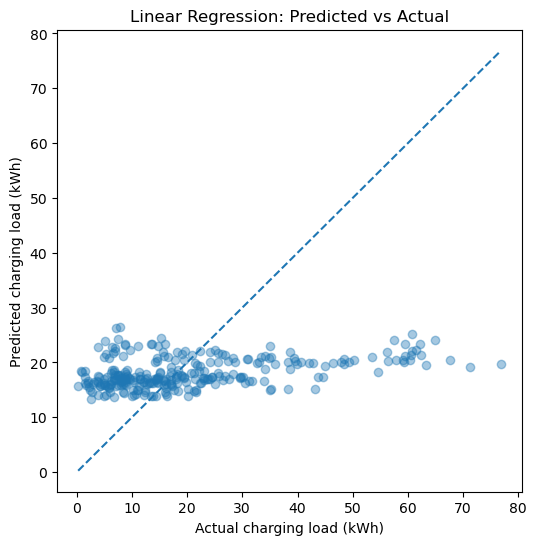

In [174]:
import numpy as np
import matplotlib.pyplot as plt

y_test_plot = np.asarray(y_test).ravel()
pred_plot = np.asarray(pred).ravel()

plt.figure(figsize=(6, 6))
plt.scatter(y_test_plot, pred_plot, alpha=0.4)

minimum = min(y_test_plot.min(), pred_plot.min())
maximum = max(y_test_plot.max(), pred_plot.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual charging load (kWh)")
plt.ylabel("Predicted charging load (kWh)")
plt.title("Linear Regression: Predicted vs Actual")
plt.show()

Looks like our mean squared error is around `131.4` (if you used different columns in your model than we did, you might have a different value). Remember, this is squared error. If we take the square root, we have about `11.5`. One way of interpreting this is to say that the linear regression, on average, is off by `11.5 kWh`.

In [175]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [176]:
import pandas as pd

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [177]:
print(X_train_scaled.mean().round(2))
print(X_train_scaled.std().round(2))

Duration_hours                          0.0
MOHOLT RAMPE 2                         -0.0
Jonsvannsveien vest for Steinanvegen    0.0
dtype: float64
Duration_hours                          1.0
MOHOLT RAMPE 2                          1.0
Jonsvannsveien vest for Steinanvegen    1.0
dtype: float64


## Task Group 5 - Train a Neural Network Using PyTorch

Let's now create a neural network using PyTorch to predict EV charging loads.

### Task 12

First, we'll need to import the PyTorch library and modules.

Import the PyTorch library `torch`.

From `torch`, import `nn` to access built-in code for constructing networks and defining loss functions.

From `torch`, import `optim` to access built-in optimizer algorithms.

In [178]:
import torch
from torch import nn
from torch import optim

In [179]:
X_train.values.shape

(1121, 3)

In [180]:
X_train.values

array([[ 11.16444444, 201.        , 796.        ],
       [  3.47833333,  59.        , 314.        ],
       [  1.15944444, 156.        , 650.        ],
       ...,
       [  2.4475    , 162.        , 597.        ],
       [ 10.8475    , 122.        , 539.        ],
       [  9.31361111,  17.        , 111.        ]], shape=(1121, 3))

### Task 13

Before training the neural network, convert the training and testing sets into PyTorch tensors and specify `float` as the data type for the values.

In [181]:
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float)
X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float)

In [182]:
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float).view(-1, 1)
y_test_tensor =  torch.tensor(y_test.values, dtype=torch.float).view(-1, 1)

### Task 14

Next, let's use `nn.Sequential` to create a neural network.

First, set a random seed using `torch.manual_seed(42)`.

Then, create a sequential neural network with the following architecture:

- input layer with number of nodes equal to the number of training features
- a first hidden layer with `56` nodes and a ReLU activation
- a second hidden layer with `26` nodes and a ReLU activation
- an output layer with `1` node

Save the network to the variable `model`.

In [183]:
torch.manual_seed(42)
input_size = X_train_tensor.shape[1]
model =  nn.Sequential(
    nn.Linear(input_size, 56),
    nn.ReLU(),
    nn.Linear(56, 26),
    nn.ReLU(),
    nn.Linear(26, 1)
)
print(model)

total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable paramters:", total_params)

Sequential(
  (0): Linear(in_features=3, out_features=56, bias=True)
  (1): ReLU()
  (2): Linear(in_features=56, out_features=26, bias=True)
  (3): ReLU()
  (4): Linear(in_features=26, out_features=1, bias=True)
)
Trainable paramters: 1733


### Task 15

Next, let's define the loss function and optimizer used for training:

- set the MSE loss function to the variable `loss`
- set the Adam optimizer to the variable `optimizer` with a learning rate of `0.0007`

In [184]:
learning_rate = 0.0007

loss = nn.MSELoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

### Task 16

Create a training loop to train our neural network for 3000 epochs.

Keep track of the training loss by printing out the MSE every 500 epochs.

In [185]:
num_epochs=3000

for epoch in range(num_epochs):
    model.train()
    
    # forward pass
    predictions = model(X_train_tensor)

    # calculae the training loss
    train_loss = loss(predictions, y_train_tensor)

    # backward pass
    train_loss.backward()

    # update weights and biases
    optimizer.step()

    # reset old gradients
    optimizer.zero_grad()

    if (epoch + 1) % 500 == 0:
        print(
            f"Epoch [{epoch + 1} / {num_epochs}], "
            f"Training MSE: {train_loss.item():.4f}"
        )


Epoch [500 / 3000], Training MSE: 178.4757
Epoch [1000 / 3000], Training MSE: 135.3348
Epoch [1500 / 3000], Training MSE: 131.5529
Epoch [2000 / 3000], Training MSE: 128.5886
Epoch [2500 / 3000], Training MSE: 126.3212
Epoch [3000 / 3000], Training MSE: 124.6221


### Task 17
Save the neural network in the `models` directory using the path `models/model.pth`.

In [186]:
os.makedirs("models", exist_ok=True)
torch.save(model, "models/model.pth")

In [187]:
device="cpu"
model=torch.load("models/model.pth",
                map_location=device,
                weights_only=False)

### Task 18

Evaluate the neural network on the testing set. 

Save the testing data loss to the variable `test_loss` and use `.item()` to extract and print out the loss. 

In [188]:
model.eval()

with torch.no_grad():
    predictions = model(X_test_tensor)
    test_loss = loss(predictions, y_test_tensor)
print("Final MSE:", test_loss.item())   

Final MSE: 167.46726989746094


In [189]:
# Neural network metrics
nn_mse = test_loss.item()
nn_rmse = np.sqrt(nn_mse)
nn_mae = mean_absolute_error(
    y_test_tensor.numpy(),
    predictions.numpy()
)

# Linear regression metrics
linear_mse = test_mse
linear_rmse = RMSE
linear_mae = MAE

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Neural Network"],
    "MSE": [linear_mse, nn_mse],
    "RMSE": [linear_rmse, nn_rmse],
    "MAE": [linear_mae, nn_mae]
})

comparison

,Model,MSE,RMSE,MAE
0,Linear Regression,241.673516,15.545852,11.474159
1,Neural Network,167.467270,12.940915,9.099774
